# Portfolio optimization

We consider the problem of choosing a *long term* stock portfolio, given a set of stocks and their price over some period under *risk aversion parameter* $\gamma \gt 0$.

Assume there are $m$ stocks to be considered.
The *portfolio* will be represented by a vector $w \in \mathbb{R}^m$, such that $\sum_{i = 1}^{m} w_i = 1$. If $w_i \gt 0$, you use a fraction $w_i$ of your total money to *buy* the $i'th$ stock, while $w_i \lt 0$ represent *<a href="https://en.wikipedia.org/wiki/Short_(finance)">shorting</a>* that stock. In both cases we assume the stock is bought/shorted for the entire period.

Let $p_{j,i}$ represent the price of the $i'th$ stock at timestep $j$. If there are $n$ timesteps, then $p \in \mathbb{R}^{n \times m}$ is a matrix.

Let $r_{j,i}$ represent the fractional reward of stock $i$ at timestep $j$, i.e. $r_{j,i} = \frac{p_{j,i} - p_{j-1,i}}{p_{j,i}}$ for $j \gt 1$.

We make the (unrealistic) assumptation that we can model $r$ model a *Random Variable*, distributed as a multivariate gaussian with *estimated* means, 

$$ \mu=\mathbb{E} \big[ r \big] \simeq \frac{1}{n} \sum_{j=1}^n r_{j} $$ 

and *estimated* variances,

$$ \Sigma=\mathbb{E} \big[ (r- \mu)(r - \mu)^T \big] \simeq \frac{1}{n} \sum_{j=1}^n \big[ (r_j- \mu)(r_j - \mu)^T \big]. $$

The distribution of *Returns* using some *w* is then just,

$$ R_w = \mathcal{N}(\mu_w, \sigma_w), \quad \mu_w = w^T\mu, \quad \sigma_w = w^T \Sigma w. $$

Now, naturaly we want to *maximize* for a balance between high return $\mu_w$ and low risk $\sigma_w$. This leads to the following optimization problem:

$$ w^* = \arg\max_w \bigg[ w^T\mu - \gamma w^T \Sigma w \bigg] $$
$$ st. \sum w_i = 1. $$

Where $\gamma$ controls the balance between *risk* and *return*. A high value of $\gamma$ indicate we are willing to take *low* risk and vise versa.

Your job is to find this $w^*$ using real stock values of your choosing, under different values of $\gamma$. To make your job easier, the task is seperated into the following subtasks:

1. We need a module for collecting stockvalues, for this we will use `googlefinance`. See [here](https://pypi.org/project/googlefinance.client/) for a desciption of how to install and use the module. Using this you should write a function `get_prices([stocks, ... ], step_size, period, exchange)`, that return a tuple, `(stocks, p)`. Where `p[i, j]` represent the **opening** price of stock $j$ at timestep $i$ and `stocks[j]` is the name of the $j'th$ stock. You should document this function by including a plot of $p$, where each stock is labeled with its name (for example `MSFT` or `GOGL`). you should use atleast 5 stocks to get good results.

2. Calculate $r$, $\mu$ and $\Sigma$ using the formulars above and the $p$ you calulated at (1). Plot the probability density function (*pdf*) of each stock. (**Hint**: `from matplotlib.mlab import normpdf` might be handy).

3. Solve the optimization problem defined above for different values of gamma (for example `gammas = (np.arange(10) / 5) + 1`) and plot the *pdf* of each solution to a single plot with apropriate legends. Finally create a scatterplot of how $w^*$ changes as $\gamma$ changes.

In [ ]:
from googlefinance.client import get_price_data, get_prices_data
from scipy.optimize import minimize
from matplotlib.mlab import normpdf

import matplotlib.pyplot as plt
import numpy as np

In [1]:
# SOLUTION TO 1

def get_prices(stocks=['MSFT', 'GOGL', 'FLWS', 'FOX', 'UHAL'], step_size=6400, period='1Y', exchange='NASD'):
    params = [{'q': stock, 'i': step_size, 'x': exchange} for stock in stocks]
    df = get_prices_data(params, period)
    
    keys = [key for key in df.keys() if "_Open" in key]
    
    return [key.replace('_Open', '') for key in keys], df.as_matrix(keys)

stocks, p = get_prices()

for name, data in zip(stocks, p.T):
    plt.plot(data, label=name)
    
plt.legend()
plt.show()

SyntaxError: expected '(' (1527555515.py, line 3)

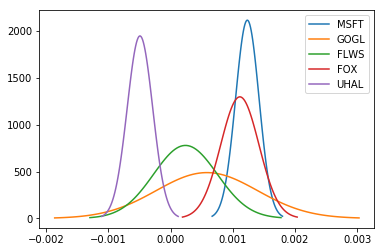

In [5]:
# SOLUTION TO 2

r = ((p - np.roll(p, 1, axis=0)) / p)[1:]
means = r.mean(axis=0)
sigma = sum(np.outer(r_ - means, r_ - means) for r_ in r) / r.shape[0]

for i in range(means.size):
    m, s = means[i], sigma[i, i]
    x = np.linspace(m - 3 * s, m + 3 * s, 100)
    
    plt.plot(x, normpdf(x, m, s), label=stocks[i])
    
plt.legend()
plt.show()

In [7]:
sigma

array([[  1.88513579e-04,   9.72500724e-05,   5.33995389e-05,
          5.69300304e-05,   4.41199454e-05],
       [  9.72500724e-05,   8.15662911e-04,   3.27950688e-05,
          1.28486206e-04,   6.33164062e-05],
       [  5.33995389e-05,   3.27950688e-05,   5.12024475e-04,
          8.36711709e-05,   4.40192990e-05],
       [  5.69300304e-05,   1.28486206e-04,   8.36711709e-05,
          3.07373614e-04,   2.93045103e-05],
       [  4.41199454e-05,   6.33164062e-05,   4.40192990e-05,
          2.93045103e-05,   2.04782799e-04]])

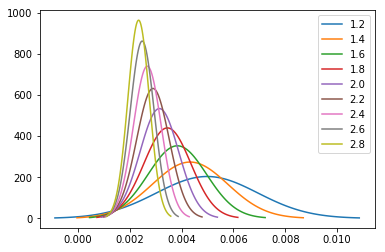

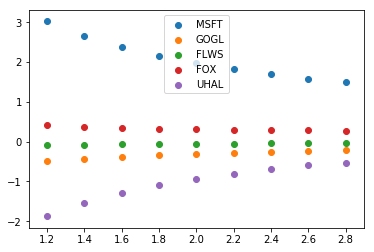

In [7]:
# SOLUTION TO 3

gammas = (np.arange(1, 10) / 5) + 1

def get_dist(x):
    m = x.T @ means
    s = x.T @ sigma @ x
    x_ = np.linspace(m - 3 * s, m + 3 * s, 100)
    return x_, normpdf(x_, m, s)

def objective_fun(gamma):
    def objective(w):
        return -(w.T @ means - gamma * w.T @ sigma @ w)
    return objective

solutions = np.array(
    list(
        i['x'] for i in (
            minimize(
                objective_fun(gamma_),
                np.array([1/len(stocks) for _ in stocks]),
                constraints={'type': 'eq', 'fun': lambda w: sum(w) - 1}
            ) 
            for gamma_ in gammas
        )
    )
)

for gamma, data in zip(gammas, solutions):
    plt.plot(*get_dist(data), label=str(gamma))
    
plt.legend()
plt.show()

for i in range(solutions.shape[1]):
    plt.scatter(gammas, solutions[:,i], label=stocks[i])
    
plt.legend()
plt.show()